<a href="https://colab.research.google.com/github/Ranjan659/Cardamom-leaf-classifier/blob/main/notebooks/01_data_setup_visualizaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cardamom Leaf vs Not-Leaf Classification

## Phase 1: Data Loading Pipeline

### Objectives
In this notebook we will:

1. Connect Google Drive to Colab
2. Load image dataset
3. Apply preprocessing transforms
4. Create batches using DataLoader
5. Visualize sample images

This is the first step before training a CNN model.

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Environment Detection Script
import torch
import platform
import psutil
import subprocess

print("="*50)
print("️  SYSTEM SPECIFICATIONS")
print("="*50)

# Hardware
print(f"\n📦 Hardware:")
print(f"   CPU: {platform.processor()}")
print(f"   CPU Cores: {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count(logical=True)} logical")
print(f"   RAM: {round(psutil.virtual_memory().total / (1024**3), 1)} GB")

# Check for GPU
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 1)} GB")
    training_device = "CUDA (GPU)"
else:
    print(f"   GPU: None detected")
    training_device = "CPU"

# Software
print(f"\n💻 Software:")
print(f"   OS: {platform.system()} {platform.release()}")
print(f"   Python: {platform.python_version()}")
print(f"   PyTorch: {torch.__version__}")
print(f"   Training Device: {training_device}")

# Colab-specific info
try:
    import subprocess
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader,nounits'],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print(f"\n🎮 Colab GPU Details:")
        print(f"   {result.stdout.strip()}")
except:
    pass

print("\n" + "="*50)
print("✅ Copy these values into your paper.md")
print("="*50)

️  SYSTEM SPECIFICATIONS

📦 Hardware:
   CPU: x86_64
   CPU Cores: 1 physical / 2 logical
   RAM: 12.7 GB
   GPU: Tesla T4
   GPU Memory: 14.6 GB

💻 Software:
   OS: Linux 6.6.122+
   Python: 3.12.13
   PyTorch: 2.10.0+cu128
   Training Device: CUDA (GPU)

🎮 Colab GPU Details:
   Tesla T4, 15360

✅ Copy these values into your paper.md


# Importing Required Libraries

We import:

- `torch` → Deep learning framework
- `torchvision` → Image datasets and transforms
- `matplotlib` → Visualization
- `os` → File handling

In [4]:
import os
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Dataset Setup

Dataset stored in Google Drive:

```text
cardamom_dataset/
└── train/
    ├── leaf/
    └── not_leaf/
```

We store the dataset location in:

```python
DATA_PATH = "/content/drive/MyDrive/cardamom_dataset/train"
```

This path tells PyTorch:

- "Go inside Google Drive"  
- "Find the dataset folder"  
- "Load images from the `train` directory"

---



In [5]:
DATA_PATH = "/content/drive/MyDrive/cardamom_dataset/train"

# Image Preprocessing

Neural networks require images of the same size.

We apply:

- `Resize(224,224)` → Standard input size
- `ToTensor()` → Converts image into tensor

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#Load Dataset

`ImageFolder` reads all images and assigns labels automatically.

#How `ImageFolder` Works

`ImageFolder` automatically:

- Reads all images inside each folder  
- Uses folder names as class labels  
- Assigns numerical labels automatically

Example:

| Folder Name | Assigned Label |
|---|---|
| `leaf` | `0` |
| `not_leaf` | `1` |

So:

- Every image inside `leaf/` becomes class `0`
- Every image inside `not_leaf/` becomes class `1`

This makes dataset loading very easy for image classification tasks.

In [7]:
cardamom_leaves_dataset = datasets.ImageFolder(
    root=DATA_PATH,
    transform=transform
)

print("✅ Classes:", cardamom_leaves_dataset.classes)
print("✅ Label Mapping:", cardamom_leaves_dataset.class_to_idx)
print("✅ Total Images:", len(cardamom_leaves_dataset))

✅ Classes: ['leaf', 'not_leaf']
✅ Label Mapping: {'leaf': 0, 'not_leaf': 1}
✅ Total Images: 60


# Create DataLoader

The DataLoader:

- Creates batches
- Shuffles data
- Feeds images during training

Batch size = 8 means:
8 images are processed together.

In [8]:
dataloader = torch.utils.data.DataLoader(
    cardamom_leaves_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

# Inspect One Batch

We fetch one batch to verify:

- image shape
- labels
- preprocessing

In [9]:
images, labels = next(iter(dataloader))

print("✅ Batch Shape:", images.shape)
print("✅ Labels:", labels)

✅ Batch Shape: torch.Size([8, 3, 224, 224])
✅ Labels: tensor([0, 1, 1, 0, 0, 1, 1, 1])


# Visualize Images

PyTorch stores images in this format:

```text
(C, H, W)
```

Where:

- `C` → Color Channels  
  (`3` for RGB images)

- `H` → Image Height  
  (number of pixels vertically)

- `W` → Image Width  
  (number of pixels horizontally)

Example:

```text
(3, 224, 224)
```

means:

- 3 color channels (Red, Green, Blue)
- Height = 224 pixels
- Width = 224 pixels

However, `matplotlib` expects images in this format:

```text
(H, W, C)
```

So we use:

```python
permute(1, 2, 0)
```

to rearrange the dimensions before displaying the image.

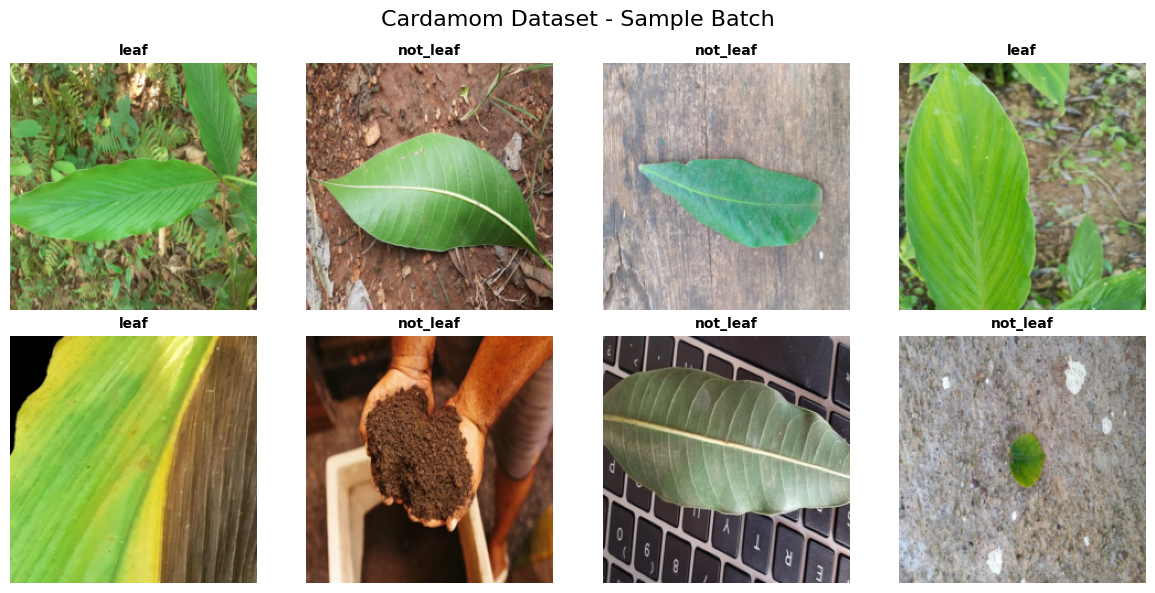

In [10]:
# Convert tensor into displayable image
def tensor_to_image(tensor):

    # Rearrange dimensions for display
    image = tensor.permute(1, 2, 0)

    # Keep pixel values between 0 and 1
    image = image.clamp(0, 1)

    return image

# Create figure and subplot grid with 2 rows and 4 columns
# figsize controls overall plot size
fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)


# axes contains all subplot boxes

# axes.flat converts the 2D grid into a simple 1D sequence for easier looping
# enumerate() adds index numbers:

# idx = image number
# ax  = current plot box
for idx, ax in enumerate(axes.flat):

    # Prevents going outside image list
    if idx < len(images):

        # Display image in current subplot
        ax.imshow(
            tensor_to_image(images[idx])
        )

        # Convert numeric label into class name
        class_name = (
            cardamom_leaves_dataset.classes[
                labels[idx]
            ]
        )

        # Add title above image
        ax.set_title(
            class_name,
            fontsize=10,
            fontweight="bold"
        )

        # Hide x-axis and y-axis
        ax.axis("off")


# Add title for entire figure
plt.suptitle(
    "Cardamom Dataset - Sample Batch",
    fontsize=16
)

# Automatically adjust spacing
# Prevents overlap between plots
plt.tight_layout()

# Display final visualization
plt.show()

# Step 2: Building a Tiny CNN Model

In this step, we create a small Convolutional Neural Network (CNN) for binary image classification.

The model will learn to classify:

- `leaf`
- `not_leaf`

### CNN Architecture

```text
Input Image
      ↓
Convolution Layers
      ↓
ReLU Activation
      ↓
Max Pooling
      ↓
Flatten
      ↓
Fully Connected Layers
      ↓
Prediction Output
```

The network contains:

- 3 Convolution layers → feature extraction
- MaxPooling → reduce image size
- Fully Connected layers → final classification

In [11]:
# Neural network module
import torch.nn as nn

# Functional operations like ReLU
import torch.nn.functional as F

#Defining CNN Architecture

The CNN learns image patterns step-by-step.

### What each layer does:

| Layer | Purpose |
|---|---|
| Conv2D | Detect features like edges, textures |
| ReLU | Adds non-linearity |
| MaxPool | Reduces image size |
| Flatten | Converts 2D features into 1D vector |
| Linear | Final classification |

The image size changes after pooling:

```text
224 × 224
    ↓
112 × 112
    ↓
56 × 56
    ↓
28 × 28
```

In [12]:
class TinyCardamomCNN(nn.Module):

    def __init__(self):

        # Initialize parent class
        super(TinyCardamomCNN, self).__init__()

        # ==================================================
        # Convolution Layers
        # ==================================================
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )


        # ==================================================
        # Pooling Layer
        # ==================================================

        # Reduces width and height by half
        #
        # Example:
        # 224 → 112
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # ==================================================
        # Fully Connected Layers
        # ==================================================

        # After 3 poolings:
        #
        # 224 → 112 → 56 → 28
        #
        # Final tensor:
        # [64, 28, 28]
        #
        # Flattened size:
        # 64 × 28 × 28 = 50176
        self.fc1 = nn.Linear(
            64 * 28 * 28,
            32
        )


        # Final output layer
        #
        # Output:
        # 1 value for binary classification
        self.fc2 = nn.Linear(
            32,
            1
        )


    # ======================================================
    # Forward Pass
    # ======================================================

    def forward(self, x):

        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv1(x))
        )

        # Shape:
        # [batch, 16, 112, 112]


        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv2(x))
        )

        # Shape:
        # [batch, 32, 56, 56]


        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv3(x))
        )

        # Shape:
        # [batch, 64, 28, 28]


        # Flatten tensor
        #
        # Example:
        # [8, 64, 28, 28]
        # →
        # [8, 50176]
        x = x.view(-1, 64 * 28 * 28)


        # Fully connected layer
        x = F.relu(self.fc1(x))


        # Final prediction
        x = self.fc2(x)

        return x

# Create Model Instance

Now we create an object of the CNN class.

This initializes all layers and prepares the network for training.

In [13]:
# Create model object
model = TinyCardamomCNN()

print("✅ Model created successfully!")

# Print architecture
print("\n📊 Model Architecture:\n")
print(model)

✅ Model created successfully!

📊 Model Architecture:

TinyCardamomCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


#Count Model Parameters

Neural networks learn using trainable parameters.

More parameters usually mean:

- more learning capacity
- but also higher risk of overfitting

We calculate:

- Total parameters
- Trainable parameters

In [14]:
# Count all parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

# Count trainable parameters only
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\n📈 Total parameters: {total_params:,}")
print(f"📈 Trainable parameters: {trainable_params:,}")


📈 Total parameters: 1,629,281
📈 Trainable parameters: 1,629,281


#Testing Forward Pass

Before training, we test whether the model works correctly.

We create a fake image tensor and pass it through the network.

This helps catch shape errors early.

In [15]:
# Create fake image
#
# Shape:
# [batch, channels, height, width]
test_input = torch.randn(
    1,
    3,
    224,
    224
)

# Pass image through model
output = model(test_input)

print("\n✅ Forward pass successful!")

print(f"\nInput shape: {test_input.shape}")

print(f"Output shape: {output.shape}")

print(
    f"Output value: "
    f"{output.item():.4f}"
)


✅ Forward pass successful!

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 1])
Output value: -0.0136


# Define Loss Function & Optimizer

Before training the CNN, we must define:

- a loss function
- an optimizer

The loss function measures prediction error.

The optimizer updates model weights to reduce that error.

For this binary classification task, we use:

- BCEWithLogitsLoss
- Adam optimizer

Why use BCEWithLogitsLoss instead of BCELoss?

BCELoss expects probability values between 0 and 1.

That means we would first need to apply:

- a Sigmoid activation function

before calculating the loss.

However, BCEWithLogitsLoss is preferred because it:

- automatically applies Sigmoid internally
- is more numerically stable
- reduces floating-point instability
- avoids gradient issues during training

In practice:

- BCELoss = Sigmoid + BCE
- BCEWithLogitsLoss = both combined safely in one function

This is the standard choice for modern binary classification models.

The optimizer used is Adam, which provides:

- adaptive learning rates
- faster convergence
- stable optimization

These settings match Section 3.2 of the research paper.

In [16]:
# Define Loss Function & Optimizer

criterion = nn.BCEWithLogitsLoss()

# Adam optimizer

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("✅ Loss function initialized")
print("✅ BCEWithLogitsLoss selected")

print("\n✅ Optimizer initialized")
print("✅ Adam optimizer (lr=0.001)")

print("\n🚀 Model ready for training!")

✅ Loss function initialized
✅ BCEWithLogitsLoss selected

✅ Optimizer initialized
✅ Adam optimizer (lr=0.001)

🚀 Model ready for training!


# Training the CNN Model

In this phase, the Convolutional Neural Network (CNN) is trained using batches of cardamom leaf images.

During training, the model performs the following steps for each batch:

1. receives a batch of input images and labels  
2. performs a forward pass to generate predictions  
3. converts logits into prediction probabilities  
4. computes the classification loss using the loss function  
5. calculates prediction accuracy  
6. performs backpropagation to compute gradients  
7. updates model weights using the optimizer  

The training process is repeated for multiple epochs so the model can gradually learn important visual patterns distingushing cardamom leaves from non-leaf backgrounds.

To monitor learning progress, the following metrics are recorded after every epoch:

- training loss  
- training accuracy  

These metrics help evaluate whether the model is learning effectively and can also help identify issues such as overfitting or unstable training behavior.

In [17]:
import time

# start timer
start_time = time.time()

# Set Epochs
NUM_EPOCHS = 20
BATCH_SIZE = 8


# Store metrics
train_losses = []
train_accuracies = []

# Create DataLoader
train_loader = torch.utils.data.DataLoader(
    cardamom_leaves_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


# Training loop
for epoch in range(NUM_EPOCHS):
  # Training loop
  model.train()

  # Reset metrics
  running_loss = 0
  correct = 0
  total = 0

  # Loop through batches
  for images, labels in train_loader:

    # Zero gradient
    optimizer.zero_grad()

    #Forward Pass
    outputs = model(images).squeeze()

    # convert logits -> probabilities
    predictions = torch.sigmoid(outputs)

    # Convert probabilities -> 0 or 1
    predicted_labels = torch.round(predictions)

    # Calculate loss
    loss = criterion(outputs, labels.float())

    # Calculate accuracy
    correct += (predicted_labels == labels.float()).sum().item()
    total += labels.size(0)



    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Store batch loss
    running_loss += loss.item()

  # EPOCH METRICS
  epoch_loss = running_loss / len(train_loader)

  epoch_accuracy = 100 * correct / total

  train_losses.append(epoch_loss)
  train_accuracies.append(epoch_accuracy)

  # Print results
  print(
      f"Epoch {epoch+1}/{NUM_EPOCHS} | "
      f"Loss: {epoch_loss:.4f} | "
      f"Accuracy: {epoch_accuracy:.2f}%"
  )

# End timer
elapsed = time.time() - start_time

print("\nTraining Complete!")
print(f"Total time: {elapsed:.2f} seconds")

Epoch 1/20 | Loss: 0.7302 | Accuracy: 41.67%
Epoch 2/20 | Loss: 0.6375 | Accuracy: 58.33%
Epoch 3/20 | Loss: 0.4136 | Accuracy: 88.33%
Epoch 4/20 | Loss: 0.3237 | Accuracy: 90.00%
Epoch 5/20 | Loss: 0.2827 | Accuracy: 90.00%
Epoch 6/20 | Loss: 0.2373 | Accuracy: 93.33%
Epoch 7/20 | Loss: 0.1931 | Accuracy: 93.33%
Epoch 8/20 | Loss: 0.1592 | Accuracy: 95.00%
Epoch 9/20 | Loss: 0.1213 | Accuracy: 96.67%
Epoch 10/20 | Loss: 0.1161 | Accuracy: 96.67%
Epoch 11/20 | Loss: 0.0953 | Accuracy: 96.67%
Epoch 12/20 | Loss: 0.0976 | Accuracy: 96.67%
Epoch 13/20 | Loss: 0.0656 | Accuracy: 98.33%
Epoch 14/20 | Loss: 0.0779 | Accuracy: 98.33%
Epoch 15/20 | Loss: 0.0363 | Accuracy: 98.33%
Epoch 16/20 | Loss: 0.0207 | Accuracy: 98.33%
Epoch 17/20 | Loss: 0.0147 | Accuracy: 100.00%
Epoch 18/20 | Loss: 0.0133 | Accuracy: 100.00%
Epoch 19/20 | Loss: 0.0119 | Accuracy: 100.00%
Epoch 20/20 | Loss: 0.0048 | Accuracy: 100.00%

Training Complete!
Total time: 96.82 seconds


# Visualizing Training Performance

Training curves help us understand how well the model learns.

We plot:

- training loss
- training accuracy

across all epochs.

These graphs help identify:

- learning progress
- convergence
- overfitting issues

The figure is also saved for inclusion in the research paper.


Plot saved at:
/content/drive/MyDrive/cardamom_dataset/docs/training_curves.png


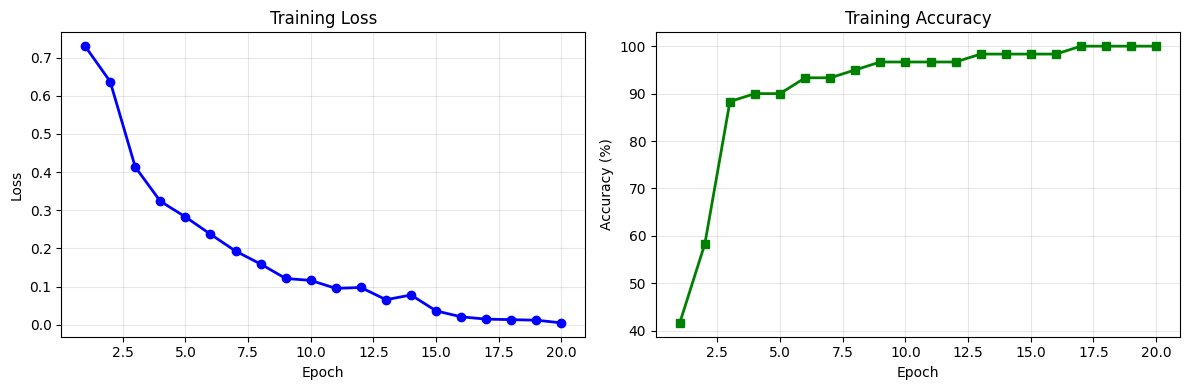

In [18]:

# Plot Training Curves
# Create epoch numbers
epochs = range(1, NUM_EPOCHS + 1)

# Create figure with 2 plots
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4)
)

# LOSS CURVE

axes[0].plot(
    epochs,
    train_losses,
    color="blue",
    marker="o",
    linewidth=2
)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# ACCURACY CURVE


axes[1].plot(
    epochs,
    train_accuracies,
    color="green",
    marker="s",
    linewidth=2
)

axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True, alpha=0.3)


# Adjust Layout


plt.tight_layout()


# Save Figure

save_dir = "/content/drive/MyDrive/cardamom_dataset/docs"

os.makedirs(save_dir, exist_ok=True)

plot_path = f"{save_dir}/training_curves.png"

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"\nPlot saved at:")
print(plot_path)

# Display Plot

plt.show()